# Ableitung mit mehreren Variablen


## Vertiefung


In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Übersicht

1. Partielle Ableitungen und Gradient darstellen
2. Gradient numerisch berechnen
3. Gradientenverfahren


### 1. Partielle Ableitungen und Gradient darstellen


Als Beispiel nehmen wir die Funktion

$$
    z = f(x,y) = -3x^2 + 5xy + y^3
$$

und betrachten zuerst mal die Höhenlinien und eine 3D-Darstellung davon.


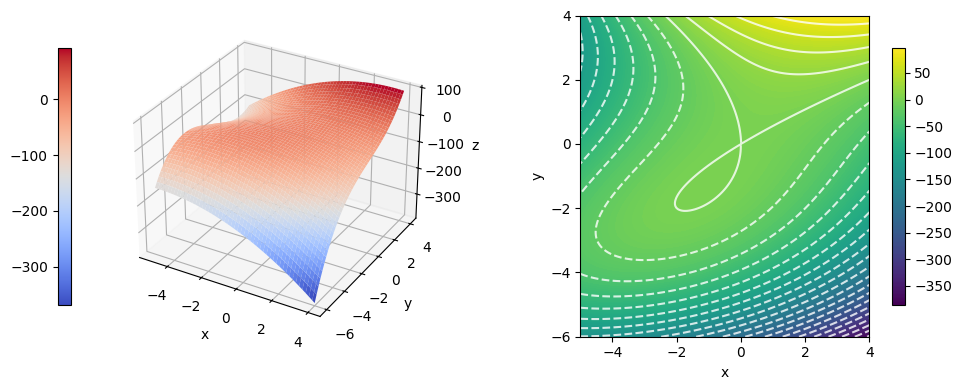

In [2]:
def f(x, y):
    return -3 * x**2 + 5 * x * y + y**3


n = 200
x = np.linspace(-5, 4, n)
y = np.linspace(-6, 4, n)
X, Y = np.meshgrid(x, y)
Z = f(X, Y)


fig = plt.figure(figsize=(10, 4))

# Fläche im Raum
ax1 = fig.add_subplot(121, projection="3d")
surf = ax1.plot_surface(X, Y, Z, cmap="coolwarm")
plt.colorbar(surf, ax=ax1, shrink=0.8, location="left")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_zlabel("z")

# Höhenlinien
ax2 = fig.add_subplot(122)
c = ax2.contourf(X, Y, Z, levels=200)
ax2.contour(X, Y, Z, levels=25, colors="w", alpha=0.8)
ax2.set_aspect("equal")
plt.colorbar(c, ax=ax2, shrink=0.8)
ax2.set_xlabel("x")
ax2.set_ylabel("y")

plt.tight_layout()
plt.show()

#### a) Partielle Ableitungen berechnen


Die beiden partiellen Ableitungen von $ f(x,y) = -3x^2 + 5xy + y^3 $ sind

\begin{align*}
\frac{\partial f}{\partial x} &\ =\ -6x + 5y \\[2ex]
\frac{\partial f}{\partial y} &\ =\ 5x + 3y^2
\end{align*}

Dies sind beides wieder Funktionen von $x$ und $y$. Wir können sie also auch wieder an einer Stelle $(x, y)$ auswerten, z.B.

\begin{align*}
f(2, 1) &\ =\ -3 \!\cdot\! 2^2 + 5 \!\cdot\! 2 \!\cdot\! 1 + 1^3 \ = \ -1 \\[2ex]
\frac{\partial f}{\partial x}(2, 1) &\ =\ -6 \!\cdot\! 2 + 5 \!\cdot\! 1 \ =\ -7 \\[2ex]
\frac{\partial f}{\partial y}(2, 1) &\ =\ 5 \!\cdot\! 2 + 3 \!\cdot\! 1^2 \ =\ 13
\end{align*}


#### b) Partielle Ableitungen darstellen


Zuerst definieren wir die analytischen Ableitungen:


In [3]:
def dfdx(x, y):
    return -6 * x + 5 * y


def dfdy(x, y):
    return 5 * x + 3 * y**2

Als Visualisierung stellen wir mal die Isokonturlinien für konstante $x$ bzw. $y$, jeweils mit der partiellen Ableitung nach $x$ bzw. $y$ darunter dar.


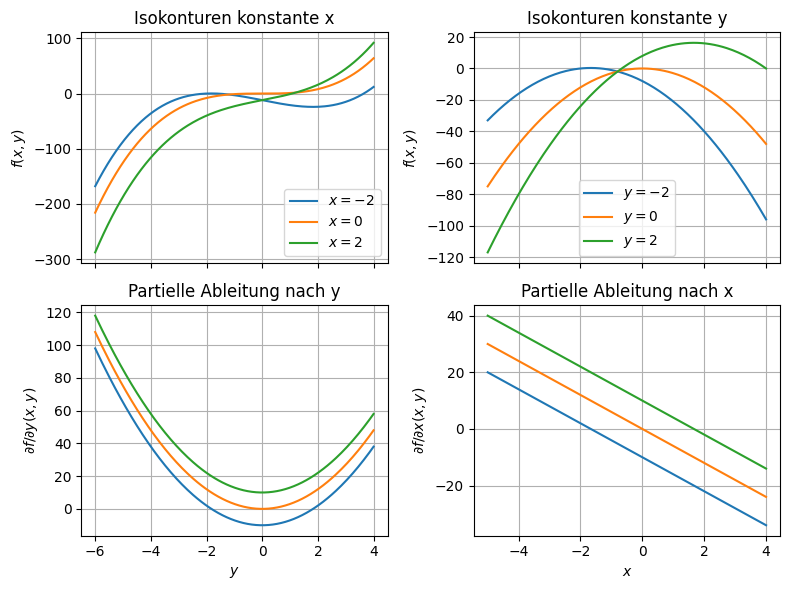

In [4]:
x_levels = [-2, 0, 2]
y_levels = [-2, 0, 2]

fig, axs = plt.subplots(2, 2, sharex="col", figsize=(8, 6))

# Isokonturen x=konst und partielle Ableitung nach y
for xi in x_levels:
    z = f(xi, y)
    z_x = dfdy(xi, y)
    axs[0, 0].plot(y, z, label=f"$x={xi}$")
    axs[1, 0].plot(y, z_x, label=f"$x={xi}$")

axs[0, 0].set_title("Isokonturen konstante x")
axs[0, 0].set_ylabel(r"$f(x, y)$")
axs[0, 0].legend()
axs[0, 0].grid()

axs[1, 0].set_title("Partielle Ableitung nach y")
axs[1, 0].set_xlabel(r"$y$")
axs[1, 0].set_ylabel(r"$\partial f / \partial y (x,y)$")
axs[1, 0].grid()

# Isokonturen y=konst und partielle Ableitung nach x
for yi in y_levels:
    z = f(x, yi)
    z_y = dfdx(x, yi)
    axs[0, 1].plot(x, z, label=f"$y={yi}$")
    axs[1, 1].plot(x, z_y, label=f"$y={yi}$")

axs[0, 1].set_title("Isokonturen konstante y")
axs[0, 1].set_ylabel(r"$f(x, y)$")
axs[0, 1].legend()
axs[0, 1].grid()

axs[1, 1].set_title("Partielle Ableitung nach x")
axs[1, 1].set_xlabel(r"$x$")
axs[1, 1].set_ylabel(r"$\partial f / \partial x (x,y)$")
axs[1, 1].grid()

plt.tight_layout()
plt.show()

Beobachtungen:

-   **$x$ konstant (links)**
    -   $f$ ist ein Polynom 3. Grades in $y$
    -   Die partielle Ableitung nach $y$ ist ein Polynom 2. Grades (quadratische Funktion).
-   **$y$ konstant (rechts)**
    -   $f$ ist ein Polynom 2. Grades in $x$
    -   Die partielle Ableitung nach $x$ ist ein Polynom 1. Grades (lineare Funktion).

Allerdings gibt diese Darstellung nur beschränkt Auskunft über die partiellen Ableitungen. Diese sind ja auch Funktionen von $x$ und $y$ und nicht nur von der einen der beiden Variablen.

Mithilfe des Gradienten können wir die lokalen Änderungsraten viel einfacher darstellen.


#### c) Gradient berechnen


Der Gradient einer Funktion $f:\mathbb{R}^n\to\mathbb{R}$, ist eine Funktion, die jedem Punkt $\vec x = (x_1, x_2, \ldots, x_n)\in\mathbb{R}^n$ den **Zeilenvektor aller partiellen Ableitungen** zuordnet:

$$
\text{grad} f(\vec x) = \begin{pmatrix} \dfrac{\partial f}{\partial x_1}(\vec x) \,, & \dfrac{\partial f}{\partial x_2}(\vec x) \,, & \ldots \,, & \dfrac{\partial f}{\partial x_n}(\vec x) \end{pmatrix}
$$

In 2 Dimensionen, d.h. für Funktionen von 2 Variablen heisst das:

$$
\text{grad} f(x,y) = \begin{pmatrix} \dfrac{\partial f}{\partial x}(x,y) \,, & \dfrac{\partial f}{\partial y}(x,y) \end{pmatrix}
$$

Häufig wird der Gradient auch mit dem Symbol $\vec\nabla$ geschrieben, um zu betonen, dass es sich um einen Vektor handelt:

$$
\vec\nabla f(\vec x) = \text{grad} f(\vec x)
$$

Das Symbol $\vec\nabla$ wird "Nabla" ausgesprochen.

Der Gradient von $f:\mathbb{R}\to\mathbb{R}$ ist also eine **vektorwertige Funktion** $\vec\nabla f:\mathbb{R}^n\to\mathbb{R}^n$. Sie ordnet jedem Vektor $\vec x\in\mathbb{R}^n$ einen Vektor $\vec\nabla f(\vec x)\in\mathbb{R}^n$ zu. Solche Funktionen werden (v.a. in der Physik) auch Vektorfelder genannt.

In folgenden Videos wird der Gradient nochmal erklärt (optional):

-   ["Gradient: Definition" - Georg Hoever](https://www.hm-kompakt.de/video?watch=932)
-   ["Gradient: Bedeutung" - Georg Hoever](https://www.hm-kompakt.de/video?watch=933)
-   ["GRADIENT berechnen – mehrdimensionale Funktion" - MathemaTrick](https://www.youtube.com/watch?v=BbOUhSRh57I)
-   ["Gradient + Richtung des steilsten Anstiegs" - MathePeter](https://www.youtube.com/watch?v=5wE5SVhe01w)


Für unser Beispiel $f(x,y) = -3x^2 + 5xy + y^3$ bedeutet dies konkret:

$$
\text{grad} f(x,y) = \begin{pmatrix} -6x + 5y \,, & 5x + 3y^2 \end{pmatrix}
$$

Wir erhalten zum Beispiel für $(x, y) = (1, 3)$:

$$
\text{grad} f(1, 3)
= \begin{pmatrix} -6\!\cdot\!1 + 5\!\cdot\!3 \,, & 5\!\cdot\!1 + 3\!\cdot\!3^2 \end{pmatrix}
= \begin{pmatrix} 9 \,, & 32 \end{pmatrix}
$$


#### d) Gradient darstellen


Für eine grafische Darstellung, können wir den Gradienten an einem Gitternetz von Punkten berechnen und als Vektorpfeile darstellen.

Dazu definieren wir zuerst eine Funktion, die den Gradienten berechnet:


In [5]:
def grad_f(x, y):
    return np.array([dfdx(x, y), dfdy(x, y)])

Dann stellen wir die Vektorpfeile mithilfe von [`plt.quiver`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.quiver.html) dar. Am anschaulichsten ist es, wenn wir die Höhenlinien der Funktion darunter darstellen.

In [`plt.quiver`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.quiver.html) sollte man für die Darstellung von Gradienten die Option `angles="xy"` setzen, damit die Pfeile in die richtige Richtung relativ zum $x$-$y$-Koordinatensystem zeigen.

Alternativ kann man ein Vektorfeld wie den Gradienten auch mithilfe von [`plt.streamplot`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.streamplot.html) darstellen.


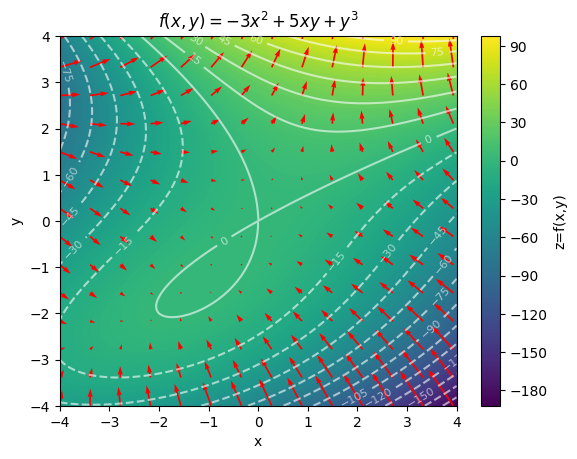

In [6]:
x_min, x_max = -4, 4
y_min, y_max = -4, 4
n = 250

# Funktionswerte für Höhenlinienplot berechnen
x = np.linspace(x_min, x_max, n)
y = np.linspace(y_min, y_max, n)
X, Y = np.meshgrid(x, y)
Z = f(X, Y)
grad_x, grad_y = grad_f(X, Y)

# Höhenlinienplot
plt.contourf(X, Y, Z, levels=200)
plt.colorbar(label="z=f(x,y)")
cs = plt.contour(X, Y, Z, levels=25, colors="w", alpha=0.6)
plt.clabel(cs, fontsize=8)

# Gradient als Vektorfeld darstellen
step = n // 13
plt.quiver(
    X[::step, ::step],
    Y[::step, ::step],
    grad_x[::step, ::step],
    grad_y[::step, ::step],
    angles="xy",
    color="r",
)

# Alternativ: Gradient als Strömungsfeld darstellen
# plt.streamplot(X, Y, grad_x, grad_y, color="r", linewidth=0.75)

plt.xlabel("x")
plt.ylabel("y")
plt.title(r"$f(x,y) = -3x^2 + 5xy + y^3$")
plt.show()

Wichtige Beobachtungen:

-   Der Gradient ist ein _Vektorfeld_, d.h. er beschreibt an jedem Punkt des Definitionsbereichs der Funktion einen Vektor.
-   Der Gradient zeigt in die _Richtung des steilsten Anstiegs_ der Funktion.
-   Der Gradient ist _senkrecht zu den Höhenlinien_ der Funktion.
-   Die Länge des Gradientenvektors ist proportional zur Steigung der Funktion.
-   Mögliche _Extremstellen_ oder _Sattelpunkte_ befinden sich dort, wo der Gradient gleich dem Null-Vektor ist.


### 2. Gradient numerisch berechnen


#### a) Numerische Berechnung des Gradienten mit zentralen Differenzen


Wie die Ableitung in einer Variablen können wir auch die partielle Ableitung mit dem zentralen Differenzenquotienten approximieren:

$$
    \frac{\partial f}{\partial x_j}(\vec x) \simeq \frac{f(x_1, \ldots, x_j + h, \ldots, x_n) - f(x_1, \ldots, x_j - h, \ldots, x_n)}{2h}
$$

wobei $f$ eine Funktion von $\vec x \in \mathbb{R}^n$ ist und $h$ eine kleine Schrittweite, z.B. $h = 5\times 10^{-6}$.

Damit kann natürlich auch der Gradient numerisch berechnet werden.

$$
    \text{grad} f(\vec x) \simeq \begin{pmatrix} \dfrac{f(x_1 + h, x_2, \ldots, x_n) - f(x_1 - h, x_2, \ldots, x_n)}{2h} \,, & \ldots \,, & \dfrac{f(x_1, x_2, \ldots, x_n + h) - f(x_1, x_2, \ldots, x_n - h)}{2h} \end{pmatrix}
$$

Wir implementieren das mal nur für Funktionen, die von 2 Variablen $x$ und $y$ abhängen.


In [7]:
def grad_2d(f, x, y, h=5e-6):
    return np.array(
        [
            (f(x + h, y) - f(x - h, y)) / (2 * h),
            (f(x, y + h) - f(x, y - h)) / (2 * h),
        ]
    )

Testen können wir dies am Beispiel aus Teil 1: $f(x,y) = -3x^2 + 5xy + y^3$.

Da hatten wir berechnet:

\begin{align*}
\text{grad} f(x,y) &= \begin{pmatrix} -6x + 5y \,, & 5x + 3y^2 \end{pmatrix} \\[2ex]
\text{grad} f(1, 3) &= \begin{pmatrix} 9 \,, & 32 \end{pmatrix}
\end{align*}


In [8]:
grad_2d(f, 1, 3), grad_f(1, 3)

(array([ 9., 32.]), array([ 9, 32]))

#### b) Numerische Berechnung des Gradienten mit `np.gradient`


[`np.gradient`](https://numpy.org/doc/stable/reference/generated/numpy.gradient.html) kann man benutzen, um den Gradienten auf Basis von Funktionswerten (Daten) zu berechnen, nicht so wie die oben implementierte Funtion `grad_2D`. Für den Vergleich müssen wir also ein paar Datenpunkte generieren.

**Vorsicht:** [`np.gradient`](https://numpy.org/doc/stable/reference/generated/numpy.gradient.html) berechnet den Gradienten in der Reihenfolge der Achsen, also Zeilen vor Spalten, und somit kommt die y-Richtung zuerst und dann die x-Richtung.


In [9]:
x0, y0 = 1, 3
h = 1e-6

x = [x0 - h, x0, x0 + h]
y = [y0 - h, y0, y0 + h]

X, Y = np.meshgrid(x, y)
Z = f(X, Y)

gradient_y, gradient_x = np.gradient(Z, y, x)

print("x-Komponente von grad f:")
print(gradient_x)
print("y-Komponente von grad f:")
print(gradient_y)

x-Komponente von grad f:
[[8.99999799 8.999995   8.99999201]
 [9.000003   9.         8.999997  ]
 [9.000008   9.000005   9.000002  ]]
y-Komponente von grad f:
[[31.999986 31.999991 31.999996]
 [31.999995 32.       32.000005]
 [32.000004 32.000009 32.000014]]


#### c) Beispiel: Himmelblau Funktion


Hier schauen wir uns nochmals ein Beispiel der [Testfunctions for Optimization](https://en.wikipedia.org/wiki/Test_functions_for_optimization) an, und zwar die [Himmelblau Funktion](https://en.wikipedia.org/wiki/Himmelblau%27s_function):


In [10]:
def himmelblau(x, y):
    return (x**2 + y - 11) ** 2 + (x + y**2 - 7) ** 2


x_min = np.array([3, -3.779310, -2.805118, 3, 3.584428])
y_min = np.array([2, -3.283186, 3.131312, 2, -1.848126])

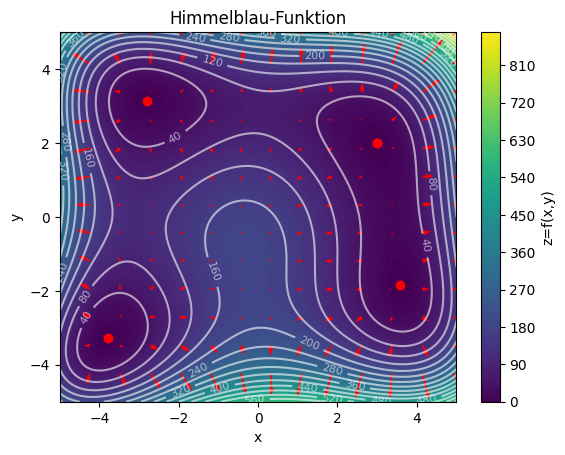

In [11]:
n = 500
x = np.linspace(-5, 5, n)
y = np.linspace(-5, 5, n)

X, Y = np.meshgrid(x, y)
Z = himmelblau(X, Y)
grad_y, grad_x = np.gradient(Z, y, x)

plt.contourf(X, Y, Z, levels=200)
plt.colorbar(label="z=f(x,y)")
cs = plt.contour(X, Y, Z, levels=25, colors="w", alpha=0.6)
plt.clabel(cs, fontsize=8)
plt.scatter(x_min, y_min, c="r")

step = n // 13
plt.quiver(
    X[::step, ::step],
    Y[::step, ::step],
    grad_x[::step, ::step],
    grad_y[::step, ::step],
    angles="xy",
    color="r",
)

# plt.streamplot(X, Y, grad_x, grad_y, color="r", linewidth=0.75)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Himmelblau-Funktion")
plt.show()

Hier beobachten wir nochmals schön, dass der Gradient weg von lokalen Minima zeigt, hin zu lokalen oder globalen Maxima. Wenn wir also ein Minimum finden wollen, müssen wir in die entgegengesetzte Richtung des Gradienten gehen.


### 3. Gradientenverfahren


Das Gradientenverfahren (engl. _Gradient Descent_) ist ein Verfahren, um die lokalen Extremstellen einer Funktion zu finden. Es ist ein iteratives Verfahren, das mit einem Startwert $\vec{x}_0$ beginnt und dann immer wieder die Iterationsvorschrift

$$
    \vec x_{i+1} = \vec x_i - \alpha_i \cdot \text{grad} f(\vec x_i)
$$

anwendet, wobei $\alpha_i$ ein Schrittweitenparameter (auch Lernrate genannt) ist.

Das folgende Video zeigt, wie das Gradientenverfahren funktioniert:

-   ["Gradientenverfahren", Georg Hoever](https://www.hm-kompakt.de/video?watch=935)


In [12]:
def gradient_descent_2d(f, x0, y0, alpha, tol, max_steps, h=5e-6):
    x, y = x0, y0
    grad = grad_2d(f, x, y, h)
    err = np.linalg.norm(grad)
    res = [(x, y, err)]
    while len(res) < max_steps and err > tol:
        x = x - alpha * grad[0]
        y = y - alpha * grad[1]
        grad = grad_2d(f, x, y, h)
        err = np.sqrt(np.sum(grad**2))
        res.append((x, y, err))
    return np.array(res)

#### Beispiel Himmelblau Funktion


Minimum gefunden: (x, y) = (2.9999999998484674, 2.0000000003545986)
Anzahl Schritte: 78
Fehlerschätzung: err = 9.99e-09
Bekannte Minima:
[[ 3.        2.      ]
 [-3.77931  -3.283186]
 [-2.805118  3.131312]
 [ 3.        2.      ]
 [ 3.584428 -1.848126]]


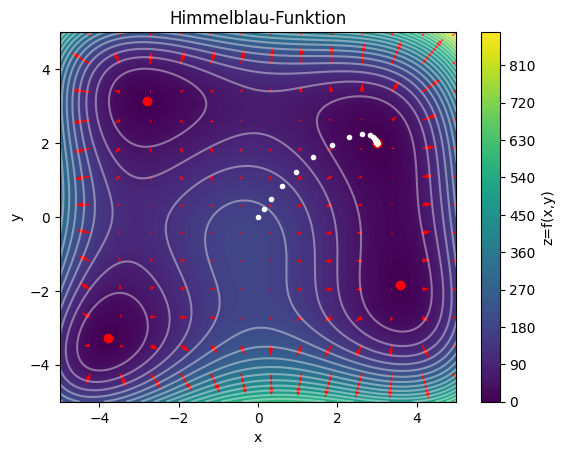

In [13]:
res = gradient_descent_2d(
    f=himmelblau,
    x0=0,
    y0=0,
    alpha=1e-2,
    tol=1e-8,
    max_steps=1000,
)
x_gd, y_gd, err = res.T

print(f"Minimum gefunden: (x, y) = ({x_gd[-1]}, {y_gd[-1]})")
print(f"Anzahl Schritte: {len(res)}")
print(f"Fehlerschätzung: err = {err[-1]:.2e}")
print("Bekannte Minima:")
print(np.array([x_min, y_min]).T)

plt.contourf(X, Y, Z, levels=200)
plt.colorbar(label="z=f(x,y)")
cs = plt.contour(X, Y, Z, levels=25, colors="w", alpha=0.4)
# plt.clabel(cs, fontsize=8)
plt.scatter(x_min, y_min, c="r")

plt.scatter(x_gd, y_gd, c="w", marker=".")

step = n // 13
plt.quiver(
    X[::step, ::step],
    Y[::step, ::step],
    grad_x[::step, ::step],
    grad_y[::step, ::step],
    angles="xy",
    color="r",
)

# plt.streamplot(X, Y, grad_x, grad_y, color="r", linewidth=0.75)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Himmelblau-Funktion")
plt.show()